# AI Photoaging Insight: Model Training and Evaluation

This notebook presents the final MobileNetV2 transfer learning model used for visible photoaging related binary classification. It includes dataset loading, preprocessing, model training, model evaluation, confusion matrix, classification report, and training performance graphs.

In [ ]:
# Import Google Drive module to access files in Colab
from google.colab import drive

# Mount Google Drive to the Colab environment
drive.mount('/content/drive')

# Path to the project dataset stored in Google Drive
DATA_PATH = "/content/drive/MyDrive/photoaging_project/data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import necessary libraries for data manipulation, visualization, and TensorFlow.
import os
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Set global constants for reproducibility, image size, batch size, and data path.
SEED = 42
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
DATA_PATH = "/content/drive/MyDrive/photoaging_project/data"

# Set random seed for TensorFlow for consistent results.
tf.keras.utils.set_random_seed(SEED)

In [ ]:
# Define a function to detect and crop a face from an image using OpenCV's Haar Cascade.
def crop_face_with_opencv(image_bgr, scale=1.2):
    if image_bgr is None:
        raise ValueError("Input image is None.")

    # Convert the image to grayscale for face detection.
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Load the Haar Cascade classifier for frontal faces.
    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    # Detect faces in the grayscale image.
    faces = detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    # If no faces are detected, return the original image.
    if len(faces) == 0:
        return image_bgr, None

    # Select the largest face found.
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    # Calculate center and side length for cropping with scaling.
    cx = x + w // 2
    cy = y + h // 2
    side = int(max(w, h) * scale)

    # Determine the cropping coordinates, ensuring they are within image bounds.
    x1 = max(cx - side // 2, 0)
    x2 = min(cx + side // 2, image_bgr.shape[1])

    # Adjust y-coordinates for a more appropriate face crop (e.g., more forehead, less chin).
    y1 = max(cy - int(side * 0.60), 0)
    y2 = min(cy + int(side * 0.40), image_bgr.shape[0])

    # Crop the image.
    cropped = image_bgr[y1:y2, x1:x2]
    return cropped, (x, y, w, h)

In [ ]:
# Define a Python function to preprocess a single image path.
def preprocess_image_path(file_path, label):
    # Decode the file path and read the image.
    file_path = file_path.numpy().decode("utf-8")
    image_bgr = cv2.imread(file_path)

    # Handle cases where the image cannot be read.
    if image_bgr is None:
        image = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)
        return image, np.float32(label)

    # Crop the face, convert to RGB, and resize the image.
    cropped_bgr, _ = crop_face_with_opencv(image_bgr)
    cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(cropped_rgb, IMG_SIZE).astype(np.float32)

    return resized, np.float32(label)


# Define a TensorFlow wrapper for the preprocessing function to use with `tf.data`.
def tf_preprocess_image_path(file_path, label):
    # Use `tf.py_function` to run the Python preprocessing function within a TensorFlow graph.
    image, label = tf.py_function(
        func=preprocess_image_path,
        inp=[file_path, label],
        Tout=[tf.float32, tf.float32],
    )
    # Set the shape of the output tensors for compatibility with TensorFlow operations.
    image.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
    label.set_shape(())
    return image, label

In [ ]:
# Configure AUTOTUNE for optimized performance of TensorFlow data pipelines.
AUTOTUNE = tf.data.AUTOTUNE

# Create TensorFlow datasets from file paths and labels for training, validation, and test sets.
# Apply shuffling, preprocessing, batching, and prefetching for efficient data loading.

# Training Dataset Setup:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_paths), seed=SEED)  # Shuffle training data.
train_ds = train_ds.map(tf_preprocess_image_path, num_parallel_calls=AUTOTUNE) # Preprocess images in parallel.
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE) # Batch and prefetch data.

# Validation Dataset Setup:
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(tf_preprocess_image_path, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Test Dataset Setup:
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(tf_preprocess_image_path, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
# Function to gather file paths and corresponding labels from a directory structure.
def get_file_paths_and_labels(split_dir):
    split_dir = Path(split_dir)
    # Get class names from subdirectories (e.g., 'negative', 'positive').
    class_names = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    # Create a mapping from class name to numerical index.
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    file_paths = []
    labels = []

    # Iterate through each class directory to collect image paths and labels.
    for class_name in class_names:
        class_dir = split_dir / class_name
        for file_path in class_dir.glob("*"):
            if file_path.is_file():
                file_paths.append(str(file_path))
                labels.append(class_to_idx[class_name])

    return file_paths, labels, class_names


# Get file paths and labels for training, validation, and testing datasets.
train_paths, train_labels, class_names = get_file_paths_and_labels(f"{DATA_PATH}/train")
val_paths, val_labels, _ = get_file_paths_and_labels(f"{DATA_PATH}/val")
test_paths, test_labels, _ = get_file_paths_and_labels(f"{DATA_PATH}/test")

# Print the detected classes and the number of samples in each split.
print("Classes:", class_names)
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Classes: ['negative', 'positive']
Train: 2130
Val: 400
Test: 383


In [ ]:
# Define a data augmentation sequential model.
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),  # Randomly flip images horizontally.
    tf.keras.layers.RandomRotation(0.1),       # Randomly rotate images by a factor of 0.1.
    tf.keras.layers.RandomZoom(0.2),          # Randomly zoom in/out on images.

    # VERY IMPORTANT: Apply random contrast and brightness adjustments for robust training.
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2),
])

In [ ]:
# Define the input layer with the specified image size and 3 color channels.
inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Apply data augmentation to the input.
x = data_augmentation(inputs)
# Apply MobileNetV2-specific preprocessing (e.g., scaling pixel values).
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

# Load a pre-trained MobileNetV2 base model without the top classification layer.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)
# Freeze the base model's layers so they are not updated during initial training.
base_model.trainable = False

# Pass the preprocessed input through the base model.
x = base_model(x, training=False)
# Apply Global Average Pooling to reduce spatial dimensions.
x = tf.keras.layers.GlobalAveragePooling2D()(x)
# Apply Batch Normalization.
x = tf.keras.layers.BatchNormalization()(x)
# Add a dense layer with ReLU activation.
x = tf.keras.layers.Dense(128, activation="relu")(x)
# Add a dropout layer to prevent overfitting.
x = tf.keras.layers.Dropout(0.4)(x)
# Output layer with sigmoid activation for binary classification.
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

# Create the full model.
model = tf.keras.Model(inputs, outputs)
# Display a summary of the model architecture.
model.summary()

/tmp/ipykernel_9720/3461541037.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# Compile the model with Adam optimizer, binary crossentropy loss, and accuracy/AUC metrics.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)
# Define an EarlyStopping callback to stop training if validation loss doesn't improve.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

# Define a ReduceLROnPlateau callback to reduce the learning rate when validation loss plateaus.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Define a ModelCheckpoint callback to save the best model weights based on validation loss.
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_photoaging_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [ ]:
# Train the model using the training and validation datasets for a specified number of epochs.
# Apply defined callbacks for early stopping, learning rate reduction, and model checkpointing.
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7549 - auc: 0.8346 - loss: 0.4935
Epoch 1: val_loss improved from None to 0.18605, saving model to best_photoaging_model.keras

Epoch 1: finished saving model to best_photoaging_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 435s 6s/step - accuracy: 0.8455 - auc: 0.9335 - loss: 0.3414 - val_accuracy: 0.9525 - val_auc: 0.9916 - val_loss: 0.1861 - learning_rate: 1.0000e-04
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9393 - auc: 0.9866 - loss: 0.1597
Epoch 2: val_loss improved from 0.18605 to 0.12184, saving model to best_photoaging_model.keras

Epoch 2: finished saving model to best_photoaging_model.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 220s 3s/step - accuracy: 0.9427 - auc: 0.9862 - loss: 0.1541 - val_accuracy: 0.9700 - val_auc: 0.9964 - val_loss: 0.1218 - learning_rate: 1.0000e-04
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9637 - auc: 0.9946 - loss: 0.0997
Epoch 3: val_loss improved from 0.12184 to

In [ ]:
# Load the best performing model saved during training.
best_model = tf.keras.models.load_model("best_photoaging_model.keras")

# Evaluate the loaded model on the test dataset.
test_loss, test_accuracy, test_auc = best_model.evaluate(test_ds)

# Print the evaluation results.
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test AUC:", test_auc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9687 - auc: 0.9980 - loss: 0.0676
Test Loss: 0.0676334947347641
Test Accuracy: 0.9686684012413025
Test AUC: 0.9979901909828186


In [ ]:
# Initialize empty lists to store true labels and predicted labels.
y_true = []
y_pred = []

# Iterate through the test dataset to get predictions.
for images, labels in test_ds:
    # Make predictions for the current batch of images.
    preds = best_model.predict(images)
    # Extend the true labels list with the ground truth labels.
    y_true.extend(labels.numpy())
    # Convert predictions to binary (0 or 1) based on a threshold (0.5) and extend the predicted labels list.
    y_pred.extend((preds.ravel() >= 0.5).astype(int))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Initialize empty lists to store true labels and predicted labels.
y_true = []
y_pred = []

# Iterate through the test dataset to get predictions.
for images, labels in test_ds:
    # Make predictions for the current batch of images.
    preds = best_model.predict(images)
    # Convert probabilities to binary labels (0 or 1) using a 0.5 threshold.
    preds = (preds > 0.5).astype(int)

    # Extend the true labels list with the ground truth labels from the current batch.
    y_true.extend(labels.numpy())
    # Extend the predicted labels list with the flattened binary predictions.
    y_pred.extend(preds.flatten())

# Compute the confusion matrix using the collected true and predicted labels.
cm = confusion_matrix(y_true, y_pred)
# Print the confusion matrix.
print(cm)
# Print a detailed classification report including precision, recall, f1-score, and support.
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
[[157  10]
 [  2 214]]
              precision    recall  f1-score   support

         0.0       0.99      0.94      0.96       167
         1.0       0.96      0.99      0.97       216

    accuracy                           0.97       383
   macro avg       0.97      0.97      0.97       383
weighted avg       0.97      0.97      0.97       383



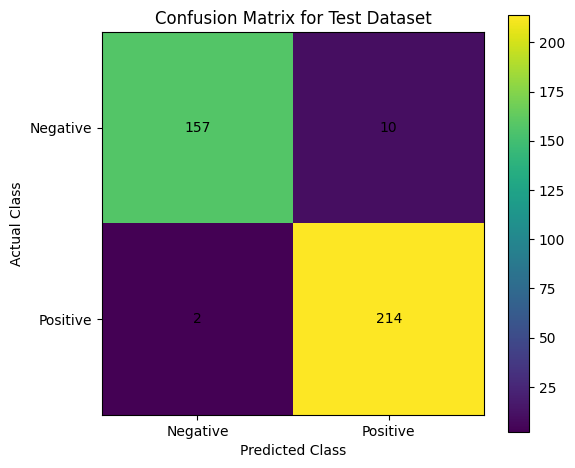

In [ ]:
# Import Matplotlib for plotting and NumPy for numerical operations.
import matplotlib.pyplot as plt
import numpy as np

# Define the confusion matrix manually based on previous output (or directly use the `cm` variable).
cm = np.array([[157, 10],
               [2, 214]])

# Define labels for the classes.
labels = ["Negative", "Positive"]

# Create a figure for the confusion matrix plot.
plt.figure(figsize=(6, 5))
# Display the confusion matrix as an image.
plt.imshow(cm)
# Set the title of the plot.
plt.title("Confusion Matrix for Test Dataset")
# Set x-axis and y-axis labels.
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
# Set x-axis and y-axis ticks and their labels.
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

# Add text annotations to each cell of the confusion matrix.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

# Add a color bar to indicate the intensity scale.
plt.colorbar()
# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the plot to a file.
plt.savefig("figure_4_confusion_matrix.png", dpi=300, bbox_inches="tight")
# Display the plot.
plt.show()

In [ ]:
# Evaluate the trained model on the validation dataset.
val_results = model.evaluate(val_ds, verbose=1)
# Evaluate the trained model on the test dataset.
test_results = model.evaluate(test_ds, verbose=1)

# Print the evaluation results for both validation and test sets.
print("Validation:", val_results)
print("Test:", test_results)

13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.9775 - auc: 0.9972 - loss: 0.0688
12/12 ━━━━━━━━━━━━━━━━━━━━ 89s 7s/step - accuracy: 0.9582 - auc: 0.9966 - loss: 0.1284
Validation: [0.0688071921467781, 0.9775000214576721, 0.9971966743469238]
Test: [0.12836571037769318, 0.9582245349884033, 0.9966456294059753]


In [ ]:
# Evaluate the trained model on the test dataset to get loss, accuracy, and AUC.
test_loss, test_acc, test_auc = model.evaluate(test_ds)

# Print the final test accuracy of the model.
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.9582 - auc: 0.9966 - loss: 0.1284
Test Accuracy: 0.9582245349884033


In [ ]:
from google.colab import drive
# Mount Google Drive, forcing a remount if it's already mounted.
drive.mount('/content/drive', force_remount=True)

# Save the trained model to a specified path in Google Drive.
model.save("/content/drive/MyDrive/photoaging_project/photoaging_model_final.keras")

Mounted at /content/drive


In [ ]:
# Import evaluation metrics and NumPy
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Temporarily set IMG_SIZE back to the original size used for model training
# This is crucial because `tf_preprocess_image_path` (used by test_ds)
# uses the global IMG_SIZE, which might have been changed by other cells.
IMG_SIZE = (256, 256)

# Lists to store true labels and predicted labels
y_true = []
y_pred = []

# Generate predictions for the test dataset
for images, labels in test_ds:
    preds = model.predict(images)              # Model predictions
    preds = (preds > 0.5).astype(int)          # Convert probabilities to binary labels

    y_true.extend(labels.numpy())              # Store true labels
    y_pred.extend(preds.flatten())             # Store predicted labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Print classification performance metrics
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[167   0]
 [ 11 205]]
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97       167
         1.0       1.00      0.95      0.97       216

    accuracy                           0.97       383
   macro avg       0.97      0.97      0.97       383
weighted avg       0.97      0.97      0.97       383



In [ ]:
# Iterate through layers of the MobileNetV2 base model.
# The base model is identified by its name, 'mobilenetv2_1.00_224'.
for layer in model.get_layer("mobilenetv2_1.00_224").layers:

    # Print the names of all convolutional layers within the base model.
    if isinstance(layer, tf.keras.layers.Conv2D):
        print(layer.name)

Conv1
expanded_conv_project
block_1_expand
block_1_project
block_2_expand
block_2_project
block_3_expand
block_3_project
block_4_expand
block_4_project
block_5_expand
block_5_project
block_6_expand
block_6_project
block_7_expand
block_7_project
block_8_expand
block_8_project
block_9_expand
block_9_project
block_10_expand
block_10_project
block_11_expand
block_11_project
block_12_expand
block_12_project
block_13_expand
block_13_project
block_14_expand
block_14_project
block_15_expand
block_15_project
block_16_expand
block_16_project
Conv_1


Mounted at /content/drive
Model loaded successfully.
Display image min: 2
Display image max: 255
Display image dtype: uint8
Model input min: -0.9843137
Model input max: 1.0
Face box: None
Prediction: 0.414082
Using Grad CAM target layer: out_relu


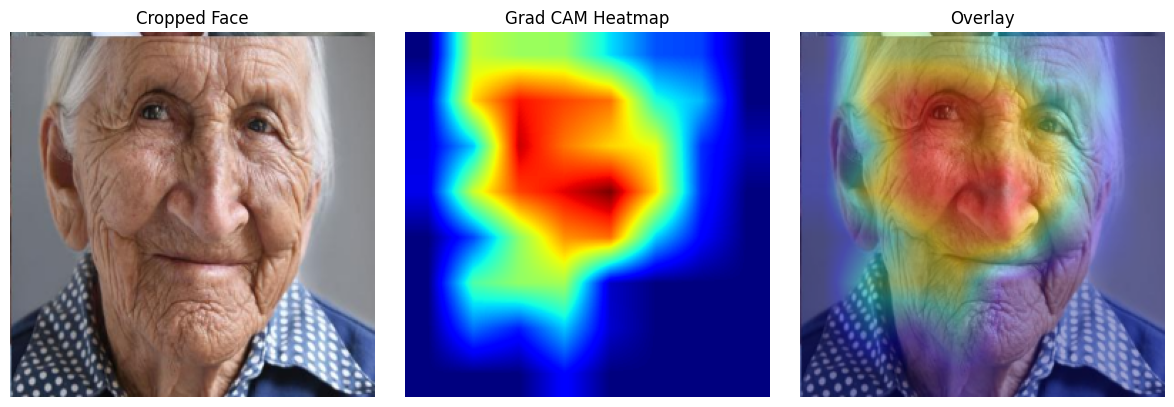

Grad CAM saved as gradcam_output.png


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import drive
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

drive.mount("/content/drive", force_remount=True)

IMG_SIZE = (256, 256)

MODEL_PATH = "/content/drive/MyDrive/photoaging_project/photoaging_model_final.keras"
SAMPLE_PATH = "/content/drive/MyDrive/photoaging_project/data/test/positive/Screenshot 2026-05-05 145013.png"

APPLY_MOBILENET_PREPROCESS = True


model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")


def crop_face_with_opencv(image_bgr, scale=1.45):
    if image_bgr is None:
        raise ValueError("Input image is None.")

    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    faces = detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 0:
        return image_bgr, None

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

    cx = x + w // 2
    cy = y + h // 2
    side = int(max(w, h) * scale)

    x1 = max(cx - side // 2, 0)
    x2 = min(cx + side // 2, image_bgr.shape[1])

    y1 = max(cy - int(side * 0.60), 0)
    y2 = min(cy + int(side * 0.40), image_bgr.shape[0])

    cropped = image_bgr[y1:y2, x1:x2]

    if cropped.size == 0:
        return image_bgr, (x, y, w, h)

    return cropped, (x, y, w, h)


def load_cropped_image_for_model(img_path, target_size=IMG_SIZE):
    image_bgr = cv2.imread(img_path)

    if image_bgr is None:
        raise ValueError(f"Could not read image: {img_path}")

    cropped_bgr, face_box = crop_face_with_opencv(image_bgr)

    cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)

    display_image = cv2.resize(cropped_rgb, target_size)

    model_image = display_image.astype(np.float32)
    model_image = np.expand_dims(model_image, axis=0)

    if APPLY_MOBILENET_PREPROCESS:
        model_image = preprocess_input(model_image)

    return model_image, display_image, face_box


def find_mobilenet_base_model(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model) and "mobilenet" in layer.name.lower():
            return layer

    raise ValueError("MobileNetV2 base model was not found inside the model.")


def find_last_conv_layer(base_model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D) or len(layer.output.shape) == 4:
            return layer.name

    raise ValueError("No suitable convolutional layer found in MobileNetV2 base model.")


def make_gradcam_heatmap(img_array, model, target_layer_name=None):
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    base_model = find_mobilenet_base_model(model)

    if target_layer_name is None:
        target_layer_name = find_last_conv_layer(base_model)

    print("Using Grad CAM target layer:", target_layer_name)

    target_layer = base_model.get_layer(target_layer_name)

    backbone_cam_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[target_layer.output, base_model.output]
    )

    classifier_layers = []
    passed_backbone = False

    for layer in model.layers:
        if layer.name == base_model.name:
            passed_backbone = True
            continue

        if passed_backbone:
            classifier_layers.append(layer)

    with tf.GradientTape() as tape:
        conv_outputs, base_features = backbone_cam_model(img_tensor, training=False)

        y = base_features
        for layer in classifier_layers:
            y = layer(y, training=False)

        preds = y
        class_score = preds[:, 0]

    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise ValueError("Gradients are None. Try a different target layer.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.nn.relu(heatmap)

    max_val = tf.reduce_max(heatmap)

    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy(), target_layer_name


def create_gradcam_visualisation(display_image, heatmap, alpha=0.35, save_path="gradcam_output.png"):
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE[1], IMG_SIZE[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        display_image.astype(np.uint8),
        1 - alpha,
        heatmap_color.astype(np.uint8),
        alpha,
        0
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(display_image.astype(np.uint8))
    plt.title("Cropped Face")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap="jet")
    plt.title("Grad CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return overlay


img_array, display_image, face_box = load_cropped_image_for_model(SAMPLE_PATH)

print("Display image min:", display_image.min())
print("Display image max:", display_image.max())
print("Display image dtype:", display_image.dtype)
print("Model input min:", img_array.min())
print("Model input max:", img_array.max())
print("Face box:", face_box)

prediction = model.predict(img_array, verbose=0)[0][0]
print("Prediction:", prediction)

heatmap, used_layer = make_gradcam_heatmap(
    img_array,
    model,
    target_layer_name=None
)

overlay = create_gradcam_visualisation(
    display_image,
    heatmap,
    alpha=0.35,
    save_path="gradcam_output.png"
)

print("Grad CAM saved as gradcam_output.png")

In [ ]:
# Iterate through the layers of the model with their index.
for i, layer in enumerate(model.layers):
    # Print the index, name, and type of each layer in the model.
    print(i, layer.name, type(layer).__name__)

0 input_layer InputLayer
1 sequential Sequential
2 mobilenetv2_1.00_224 Functional
3 global_average_pooling2d GlobalAveragePooling2D
4 batch_normalization BatchNormalization
5 dense Dense
6 dropout Dropout
7 dense_1 Dense


In [ ]:
# -----------------------------------------
# LOAD AIR POLLUTION DATASET
# -----------------------------------------
# Import TensorFlow for building and training the model
import tensorflow as tf
import pandas as pd

# Define the path to the AQI dataset.
AQI_PATH = "/content/drive/MyDrive/photoaging_project/AQI and Lat Long of Countries.csv"

# Load the AQI dataset into a pandas DataFrame.
aqi_df = pd.read_csv(AQI_PATH)

# Keep only relevant columns: "City", "Country", and "PM2.5 AQI Value".
aqi_df = aqi_df[["City","Country","PM2.5 AQI Value"]]

# Rename columns for simplicity and easier access.
aqi_df.columns = ["city","country","pm25_aqi"]

# Remove rows with any missing values.
aqi_df = aqi_df.dropna()

# Convert city and country names to lowercase for consistent matching.
aqi_df["city"] = aqi_df["city"].str.lower()
aqi_df["country"] = aqi_df["country"].str.lower()

# Aggregate by city and country, averaging PM2.5 AQI values for duplicate entries.
aqi_df = aqi_df.groupby(["city","country"], as_index=False).mean()

# Print confirmation that the dataset is loaded and its size.
print("Pollution dataset loaded.")
print("Total cities:", len(aqi_df))

Pollution dataset loaded.
Total cities: 13956


In [ ]:
import difflib

# Function to retrieve PM2.5 AQI for a given city.
def get_city_pm25(city_name):

    # Clean and normalize the input city name.
    city_name = city_name.strip().lower()

    # Find exact matches for the city name in the AQI DataFrame.
    matches = aqi_df[aqi_df["city"] == city_name]

    # If exactly one match is found, return its PM2.5 AQI value.
    if len(matches) == 1:
        return float(matches.iloc[0]["pm25_aqi"])

    # If multiple matches are found, prompt the user to select one.
    if len(matches) > 1:
        print("\nMultiple cities found with that name:")

        for i, row in matches.iterrows():
            print(f"{i}: {row['city'].title()}, {row['country'].title()}")

        selection = int(input("Select the correct city number: "))
        return float(aqi_df.loc[selection]["pm25_aqi"])

    # If no exact match is found, suggest closest cities using `difflib`.
    print("\nCity not found.")

    suggestions = difflib.get_close_matches(city_name, aqi_df["city"].unique(), n=5)

    if suggestions:
        print("Did you mean one of these?")
        for s in suggestions:
            print("-", s.title())

    return None

    # -----------------------------------------
# CONVERT AQI TO POLLUTION RISK SCORE
# -----------------------------------------

# Function to normalize PM2.5 AQI into a pollution risk score (0.0 to 1.0).
def normalize_pm25_aqi(aqi):

    # Handle cases where AQI is None, assigning a default risk.
    if aqi is None:
        return 0.6

    # Assign risk scores based on AQI ranges.
    if aqi <= 50:
        return 0.2

    elif aqi <= 100:
        return 0.4

    elif aqi <= 150:
        return 0.6

    elif aqi <= 200:
        return 0.8

    else:
        return 1.0

In [ ]:
# ============================================================
# PHOTOAGING BURDEN INDEX (PBI)
# Combines CNN visible photoaging prediction with lifestyle exposure factors
# ============================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from PIL import Image
import io

# ------------------------------------------------------------
# LOAD TRAINED MODEL
# ------------------------------------------------------------

# Define the path to the trained model.
MODEL_PATH = "/content/drive/MyDrive/photoaging_project/photoaging_model_v1.keras"
# Load the Keras model.
model = tf.keras.models.load_model(MODEL_PATH)

# Set image size and base model names for consistency.
IMG_SIZE = (224, 224)
BASE_MODEL_NAME = "mobilenetv2_1.00_224"
LAST_CONV_LAYER_NAME = "Conv_1"

# ------------------------------------------------------------
# IMAGE UPLOAD
# ------------------------------------------------------------

print("\nUpload a clear frontal face image.")
# Prompt the user to upload an image.
uploaded = files.upload()

# Get the name of the uploaded image file.
image_name = list(uploaded.keys())[0]
# Open and resize the image for model input.
img_pil = Image.open(io.BytesIO(uploaded[image_name])).convert("RGB")
img_resized = img_pil.resize(IMG_SIZE)

# Convert the image to a NumPy array and add batch dimension.
img_array = np.array(img_resized).astype(np.float32)
img_array = np.expand_dims(img_array, axis=0)

# ------------------------------------------------------------
# CNN VISIBLE PHOTOAGING SCORE
# ------------------------------------------------------------

# Preprocess the image for MobileNetV2 and get the model's prediction.
x_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
prediction = model.predict(x_preprocessed, verbose=0)
# Extract the visible photoaging probability.
P_vis = float(prediction[0, 0])

# ------------------------------------------------------------
# LIFESTYLE QUESTIONNAIRE
# ------------------------------------------------------------

print("\n=== Lifestyle Questionnaire ===")

# Ask user for hours spent outdoors.
hours_outdoors = float(
    input("How many hours do you on average spend outdoors per day? (0–8): ")
)

# Ask user about cigarette smoking.
cigs_per_day = int(
    input("Do you smoke cigarettes? If yes, how many per day? (0 if none): ")
)

# --- Pollution input with validation ---
pm25_value = None

# Loop until a valid city and its PM2.5 value are obtained.
while pm25_value is None:

    city = input("Which city do you live in most of the time? ")
    pm25_value = get_city_pm25(city)

# Ask user about daily sunscreen use.
sunscreen_use = input(
    "Do you apply sunscreen daily? (yes/no): "
).strip().lower()

# ------------------------------------------------------------
# NORMALIZATION FUNCTIONS
# ------------------------------------------------------------

# Helper function to clamp a value between 0.0 and 1.0.
def clamp01(x):
    return float(max(0.0, min(1.0, x)))

# Normalize UV exposure.
U = clamp01(hours_outdoors / 6.0)

# Normalize smoking exposure.
S = clamp01(cigs_per_day / 20.0)

# Normalize pollution exposure using the AQI dataset.
P = normalize_pm25_aqi(pm25_value)

print("\nPollution Data:")
print("City PM2.5 AQI:", pm25_value)
print("Pollution Risk Score:", round(P, 3))

# Convert sunscreen usage to a protection modifier.
C_protection = {"yes": 1.0, "no": 0.0}.get(sunscreen_use, 0.0)

# ------------------------------------------------------------
# EXPOSURE RISK SCORE
# ------------------------------------------------------------

# Define weights for different exposure factors.
W_UV = 0.70
W_SMOKE = 0.15
W_POLL = 0.10
W_SUNSCREEN = 0.05

# Calculate the combined exposure risk score.
R_exp = (
    W_UV * U +
    W_SMOKE * S +
    W_POLL * P +
    W_SUNSCREEN * (1 - C_protection)
)

# Clamp the exposure risk score between 0.0 and 1.0.
R_exp = clamp01(R_exp)

# ------------------------------------------------------------
# FINAL PHOTOAGING BURDEN INDEX
# ------------------------------------------------------------

# Define the weighting factor for visible photoaging vs. exposure risk.
ALPHA = 0.80

# Calculate the Photoaging Burden Index (PBI).
PBI = clamp01(
    ALPHA * P_vis +
    (1 - ALPHA) * R_exp
)

# ------------------------------------------------------------
# CATEGORY INTERPRETATION
# ------------------------------------------------------------

# Function to categorize the PBI score into 'Low', 'Moderate', or 'High'.
def category(score):

    if score < 0.33:
        return "Low"

    elif score < 0.66:
        return "Moderate"

    else:
        return "High"

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n=== Photoaging Burden Results ===")

# Print all calculated scores and the severity category.
print("Visible Photoaging Probability:", round(P_vis, 4))
print("Exposure Risk Component:", round(R_exp, 4))
print("Final Photoaging Burden Index:", round(PBI, 4))
print("Severity Category:", category(PBI))

print("\nNormalized Factors:")
print("UV:", round(U, 3))
print("Smoking:", round(S, 3))
print("Pollution:", round(P, 3))
print("Sunscreen Protection:", round(C_protection, 3))


Upload a clear frontal face image.


KeyboardInterrupt: 

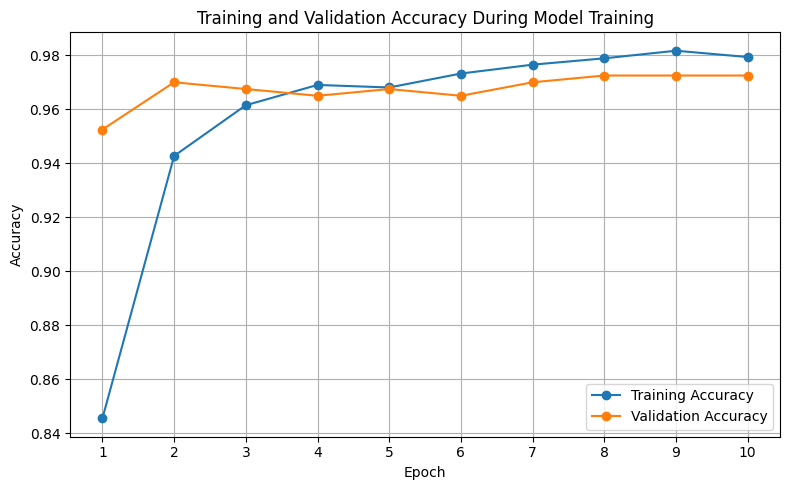

In [ ]:
# Import Matplotlib for plotting and NumPy for numerical operations.
import matplotlib.pyplot as plt
import numpy as np

# Create an array of epochs for the x-axis based on the length of the training history.
epochs = np.arange(1, len(history_head.history["accuracy"]) + 1)

# Create a figure for the plot.
plt.figure(figsize=(8, 5))
# Plot training accuracy with markers.
plt.plot(epochs, history_head.history["accuracy"], marker="o", label="Training Accuracy")
# Plot validation accuracy with markers.
plt.plot(epochs, history_head.history["val_accuracy"], marker="o", label="Validation Accuracy")
# Set plot title and labels.
plt.title("Training and Validation Accuracy During Model Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
# Set x-axis ticks to correspond to epochs.
plt.xticks(epochs)
# Display legend.
plt.legend()
# Add a grid for better readability.
plt.grid(True)
# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the plot to a file.
plt.savefig("figure_4_initial_training_accuracy.png", dpi=300, bbox_inches="tight")
# Display the plot.
plt.show()

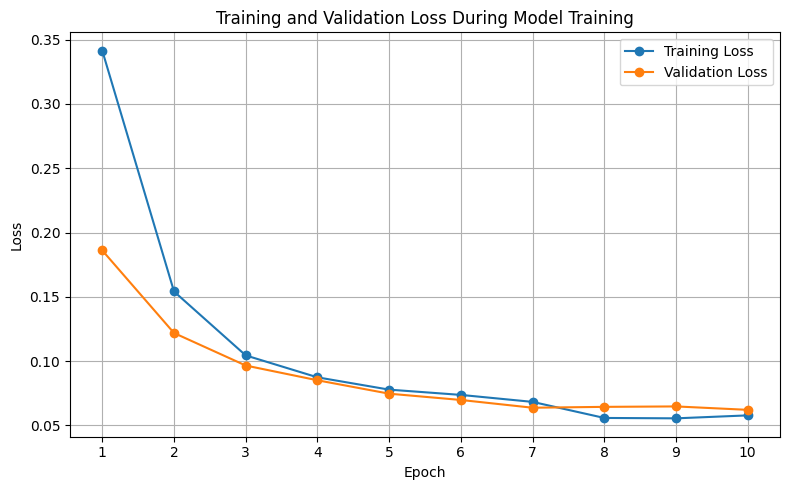

In [ ]:
# Import Matplotlib for plotting and NumPy for numerical operations.
import matplotlib.pyplot as plt
import numpy as np

# Create an array of epochs for the x-axis based on the length of the training history.
epochs = np.arange(1, len(history_head.history["loss"]) + 1)

# Create a figure for the plot.
plt.figure(figsize=(8, 5))
# Plot training loss with markers.
plt.plot(epochs, history_head.history["loss"], marker="o", label="Training Loss")
# Plot validation loss with markers.
plt.plot(epochs, history_head.history["val_loss"], marker="o", label="Validation Loss")
# Set plot title and labels.
plt.title("Training and Validation Loss During Model Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
# Set x-axis ticks to correspond to epochs.
plt.xticks(epochs)
# Display legend.
plt.legend()
# Add a grid for better readability.
plt.grid(True)
# Adjust layout to prevent labels from overlapping.
plt.tight_layout()
# Save the plot to a file.
plt.savefig("figure_4_initial_training_loss.png", dpi=300, bbox_inches="tight")
# Display the plot.
plt.show()